In [ ]:
mkdir -p ~/.kaggle && echo "YOUR_KAGGLE_API_TOKEN" > ~/.kaggle/access_token && chmod 600 ~/.kaggle/access_token

In [2]:
import os

print("Fetching files from Kaggle......")
!kaggle datasets download -d gti-upm/leapgestrecog

print("Unpacking......")
!unzip -q leapgestrecog.zip -d hand_gesture_data

path = "hand_gesture_data/leapGestRecog"
if os.path.exists(path):
    subjects = os.listdir(path)
    print(f"\nSystem checking -- PASSED")
    print(f"Subject folders: {subjects}")
else:
    print("\nThe folder was not created. Please check the dataset download status")


Fetching files from Kaggle......
Dataset URL: https://www.kaggle.com/datasets/gti-upm/leapgestrecog
License(s): CC-BY-NC-SA-4.0
100% 2.13G/2.13G [00:16<00:00, 138MB/s]

Unpacking......

System checking -- PASSED
Subject folders: ['09', '05', '00', '08', '06', '07', '03', '02', '01', '04']


In [3]:
import os
import cv2
import numpy as np
from sklearn.model_selection import train_test_split

BASE_PATH = "hand_gesture_data/leapGestRecog"
IMG_SIZE = 64  # Resizing to 64x64

X = []  # image data
y = []  # numeric labels

gesture_mapping = {
    '01_palm': 0, '02_l': 1, '03_fist': 2, '04_fist_moved': 3, '05_thumb': 4,
    '06_index': 5, '07_ok': 6, '08_palm_moved': 7, '09_c': 8, '10_down': 9
}

print("Loading and preprocessing images...")

for subject in sorted(os.listdir(BASE_PATH)):
    subject_path = os.path.join(BASE_PATH, subject)

    if not os.path.isdir(subject_path):
        continue

    for gesture_folder in os.listdir(subject_path):
        gesture_path = os.path.join(subject_path, gesture_folder)

        if not os.path.isdir(gesture_path) or gesture_folder not in gesture_mapping:
            continue

        label = gesture_mapping[gesture_folder]

        for img_name in os.listdir(gesture_path):
            img_path = os.path.join(gesture_path, img_name)

            try:
                img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
                # Resize to 64x64
                img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
                X.append(img)
                y.append(label)
            except Exception as e:
                continue

X = np.array(X, dtype="float32")
y = np.array(y, dtype="int32")

X = X.reshape(-1, IMG_SIZE, IMG_SIZE, 1)
X = X / 255.0

print(f"\nPreprocessing Completed!!!")
print(f"Total processed images (X shape): {X.shape}")
print(f"Total labels loaded (Y shape): {y.shape}")

# Spliting the dataset:- 80% for Training, 20% for Testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Training set size: {X_train.shape[0]} images")
print(f"Testing set size: {X_test.shape[0]} images")

Loading and preprocessing images...

Preprocessing Completed!!!
Total processed images (X shape): (20000, 64, 64, 1)
Total labels loaded (Y shape): (20000,)
Training set size: 16000 images
Testing set size: 4000 images


In [4]:
import tensorflow as tf
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(64, 64, 1)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(10, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       589,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 683,914 (2.61 MB)

 Trainable params: 683,914 (2.61 MB)

 Non-trainable params: 0 (0.00 B)

In [5]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

print("Starting training process on GPU.......")

# Training the model
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=64,
    validation_data=(X_test, y_test),
    callbacks=[early_stopping]
)

print("\nModel training has been completed!!!")


Starting training process on GPU.......
Epoch 1/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 12s 23ms/step - accuracy: 0.8270 - loss: 0.5163 - val_accuracy: 0.9965 - val_loss: 0.0161
Epoch 2/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - accuracy: 0.9852 - loss: 0.0504 - val_accuracy: 1.0000 - val_loss: 0.0024
Epoch 3/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9912 - loss: 0.0292 - val_accuracy: 1.0000 - val_loss: 0.0010
Epoch 4/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.9949 - loss: 0.0181 - val_accuracy: 0.9990 - val_loss: 0.0021
Epoch 5/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.9929 - loss: 0.0240 - val_accuracy: 0.9998 - val_loss: 0.0014
Epoch 6/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9958 - loss: 0.0143 - val_accuracy: 0.9998 - val_loss: 9.2951e-04
Epoch 7/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9960 - loss: 0.0122 - val_accuracy: 0.9998 - val_loss: 0.0018
Epoch 8/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/ste

Generating evaluation metrics...
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

---------------- CLASSIFICATION REPORT ----------------
               precision    recall  f1-score   support

      01_palm       1.00      1.00      1.00       400
         02_l       1.00      1.00      1.00       400
      03_fist       1.00      1.00      1.00       400
04_fist_moved       1.00      1.00      1.00       400
     05_thumb       1.00      1.00      1.00       400
     06_index       1.00      1.00      1.00       400
        07_ok       1.00      1.00      1.00       400
08_palm_moved       1.00      1.00      1.00       400
         09_c       1.00      1.00      1.00       400
      10_down       1.00      1.00      1.00       400

     accuracy                           1.00      4000
    macro avg       1.00      1.00      1.00      4000
 weighted avg       1.00      1.00      1.00      4000



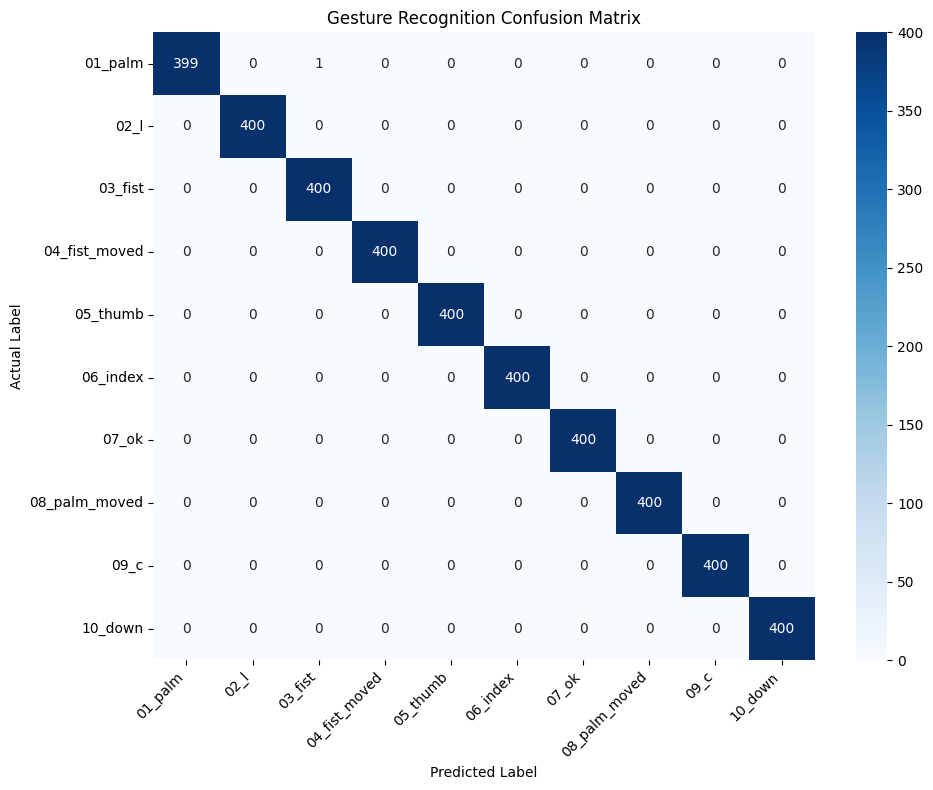

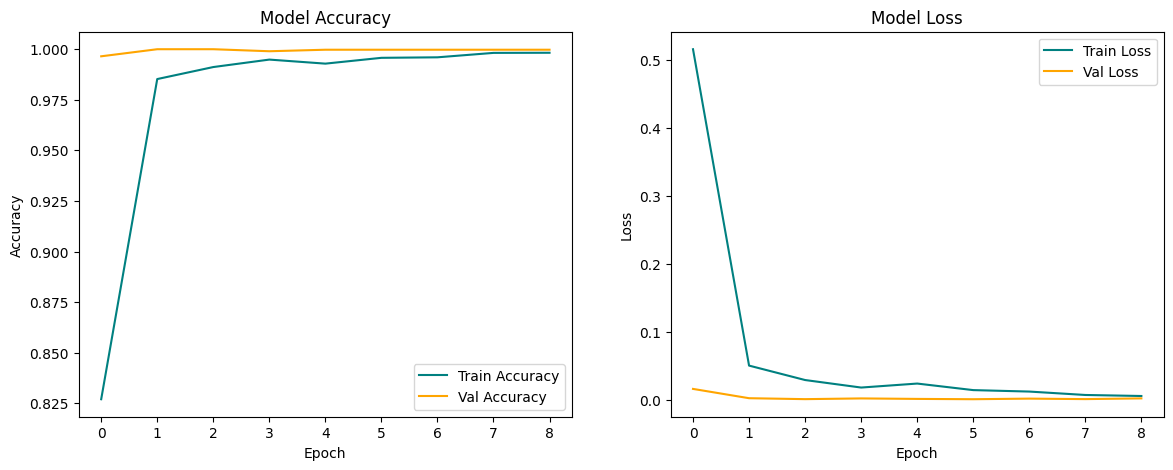

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

print("Generating evaluation metrics...")
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1) # Convert probs to class ints

# Text Classification Report
target_names = [
    '01_palm', '02_l', '03_fist', '04_fist_moved', '05_thumb',
    '06_index', '07_ok', '08_palm_moved', '09_c', '10_down'
]

print("\n---------------- CLASSIFICATION REPORT ----------------")
print(classification_report(y_test, y_pred, target_names=target_names))

# Plotting Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names)
plt.title('Gesture Recognition Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history.history['accuracy'], label='Train Accuracy', color='teal')
ax1.plot(history.history['val_accuracy'], label='Val Accuracy', color='orange')
ax1.set_title('Model Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()

ax2.plot(history.history['loss'], label='Train Loss', color='teal')
ax2.plot(history.history['val_loss'], label='Val Loss', color='orange')
ax2.set_title('Model Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()

plt.show()


In [7]:
import os
import tensorflow as tf
import numpy as np

m_name = "hand_gesture_model.keras"
model.save(m_name)
print(f"Success: Model saved securely as '{m_name}'")

print("Testing the saved model file.......")
loaded_model = tf.keras.models.load_model(m_name)

# Testing
sample_idx = np.random.randint(0, len(X_test))
sample_image = X_test[sample_idx]
actual_idx = y_test[sample_idx]

input_batch = np.expand_dims(sample_image, axis=0)

prediction_probabilities = loaded_model.predict(input_batch, verbose=0)
predicted_idx = np.argmax(prediction_probabilities)

class_names = list(gesture_mapping.keys())
print(f"\nVerification Test:")
print(f" -- Ground Truth Actual Gesture: {class_names[actual_idx]}")
print(f" -- Saved Model Predicted Gesture: {class_names[predicted_idx]}")

if actual_idx == predicted_idx:
    print("Verification successful!!!")
else:
    print("Error during loading verification")


Success: Model saved securely as 'hand_gesture_model.keras'
Testing the saved model file.......

Verification Test:
 -- Ground Truth Actual Gesture: 02_l
 -- Saved Model Predicted Gesture: 02_l
Verification successful!!!


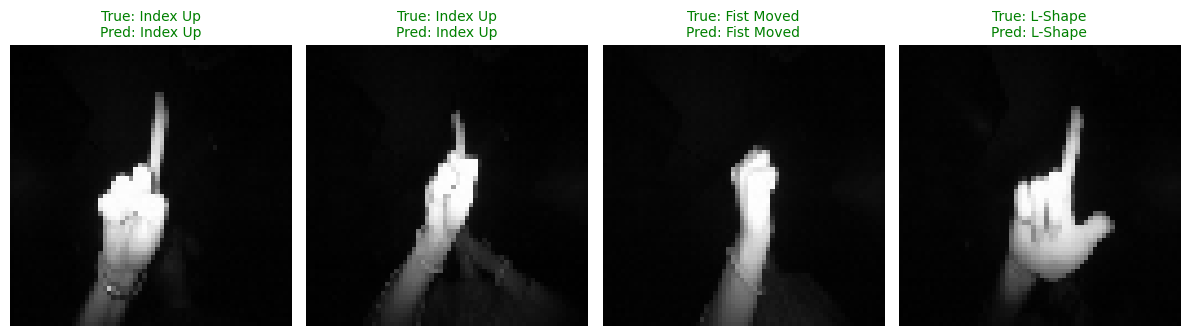

In [14]:
import matplotlib.pyplot as plt
import random
import numpy as np

random_inds = random.sample(range(len(X_test)), 4)

class_names = [
    'Palm', 'L-Shape', 'Fist', 'Fist Moved', 'Thumb',
    'Index Up', 'OK Sign', 'Palm Moved', 'C-Shape', 'Down Sign'
]

plt.figure(figsize=(12, 5))

for i, idx in enumerate(random_inds):
    plt.subplot(1, 4, i + 1)

    img_square = X_test[idx].reshape(64, 64)
    plt.imshow(img_square, cmap='gray')

    actual_idx = y_test[idx]
    predicted_idx = y_pred[idx]

    actual_label = class_names[actual_idx]
    predicted_label = class_names[predicted_idx]

    title_color = 'green' if actual_idx == predicted_idx else 'red'

    plt.title(f"True: {actual_label}\nPred: {predicted_label}", color=title_color, fontsize=10)
    plt.axis('off')

plt.tight_layout()
plt.show()
